# Mini-Project 2: Death Prediction due to covid Prediction in King County, USA

### Project Overvide:

1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Data Transformation
4. Statistical Testing
5. Model Preparation and Evaluation
6. Advanced Model: 1D Convolutional Layers Ith ANN

We will use various models such as Linear Regression, SVM, Random Forest, and more, to evaluate the dataset and identify the best perforIng model. We will also assess overfitting/underfitting using error curves.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
import scipy.stats as stats


## 1. Data Loading and Initial Inspection
Start by loading the dataset and performing initial inspections to understand the data's structure, missing values, and types.


In [2]:
# Load the dataset
url = "https://raw.githubusercontent.com/nytimes/covid-19-data/master/us-counties-recent.csv"
data = pd.read_csv(url)

# Display the first few rows
data.head()

# Summary statistics
data.describe()

# Checking for missing values
data.isnull().sum()



date         0
county       0
state        0
fips      1101
cases        0
deaths    2340
dtype: int64

## 2. Data Cleaning
Data cleaning is a crucial step in preparing our dataset for analysis. We'll handle missing values, outliers, and incorrect data types.


In [3]:
import pandas as pd
import numpy as np
from scipy import stats

# missing values for numeric columns with the mean
numeric_cols = data.select_dtypes(include=[np.number]).columns
data.loc[:, numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

# categorical columns missing values with the mode
categorical_cols = data.select_dtypes(include=[object]).columns
for col in categorical_cols:
    data.loc[:, col] = data[col].fillna(data[col].mode()[0])

# Removing outliers using Z-score
z_scores = np.abs(stats.zscore(data[numeric_cols]))
data = data[(z_scores < 3).all(axis=1)]

 

## 3. Exploratory Data Analysis (EDA)
EDA helps us understand the relationships between variables, distribution of the target variable, and other key insights.


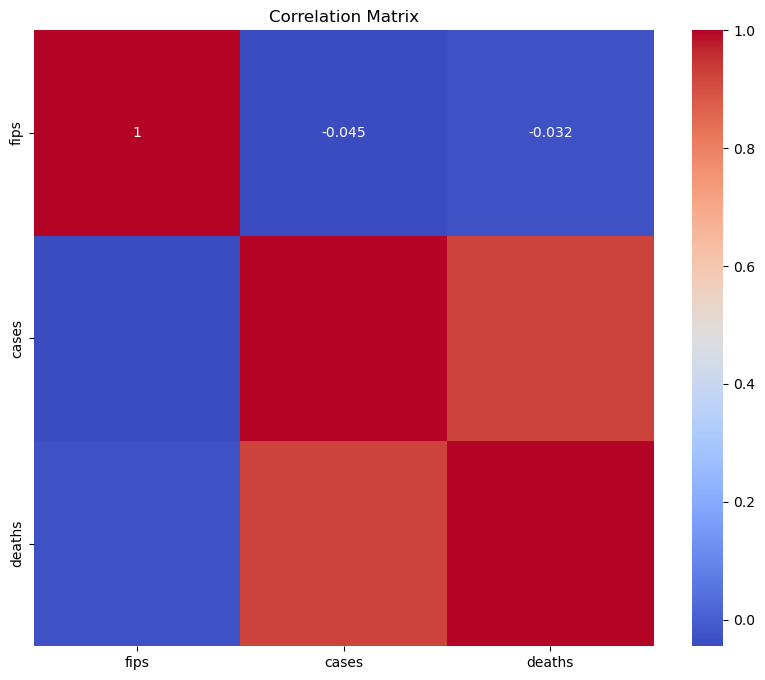

C:\Users\LENOVO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


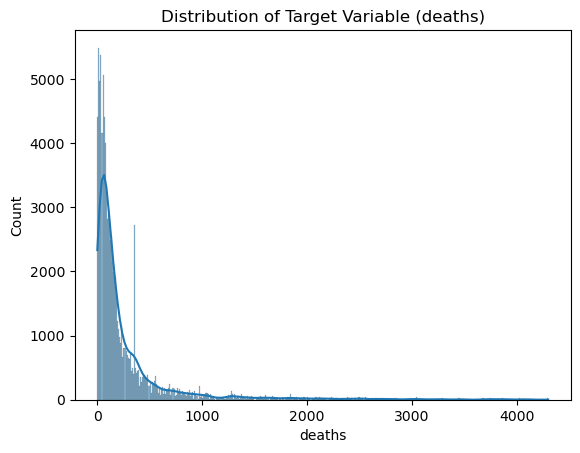

C:\Users\LENOVO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\LENOVO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\LENOVO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


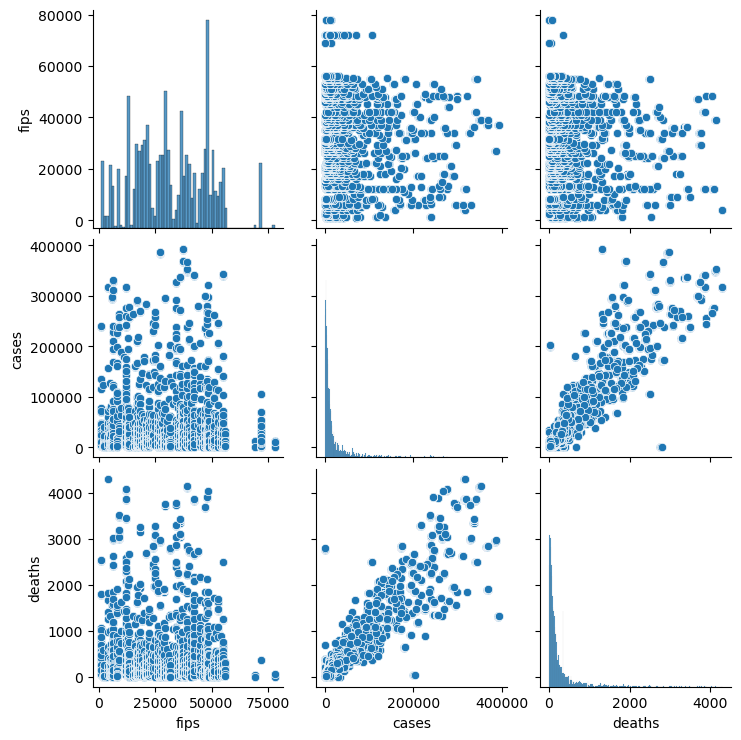

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

 
target_variable = 'deaths'  

# Handle infinite values
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Selecting only numeric columns for correlation
numeric_data = data.select_dtypes(include=[np.number])

# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Check if the target variable is present in the dataset
if target_variable in data.columns:
    sns.histplot(data[target_variable], kde=True)
    plt.title(f'Distribution of Target Variable ({target_variable})')
    plt.show()
else:
    print(f"Target variable '{target_variable}' is not present in the dataset.")

# Pairplot for key variables 
sns.pairplot(numeric_data)
plt.show()

import warnings

 
warnings.filterwarnings('ignore')


 ## 4. Data Transformation
Transformations such as scaling or encoding categorical variables will be applied to make the data suitable for model training.


In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
 
data = pd.get_dummies(data, drop_first=True)
 
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data.drop('deaths', axis=1))

 
X = pd.DataFrame(scaled_features, columns=data.drop('deaths', axis=1).columns)
y = data['deaths']


## 5. Statistical Testing  perform hypothesis tests to check for normality, correlation significance, etc.


In [6]:
# Shapiro-Wilk test for normality
shapiro_test = stats.shapiro(data['deaths'])
print('Shapiro-Wilk Test:', shapiro_test)
 


Shapiro-Wilk Test: ShapiroResult(statistic=0.5239801406860352, pvalue=0.0)


## 6. Model Training and EvaluationNnow train several regression models and evaluate their performance using metrics such as RMSE and R-squared.


In [7]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
   
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor()
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'R2 Score': r2}
    print(f'{name} - RMSE: {rmse}, R2 Score: {r2}')

# Display results
pd.DataFrame(results).T


Linear Regression - RMSE: 102.15647562635023, R2 Score: 0.9550164344814831
Decision Tree - RMSE: 16.31714472597685, R2 Score: 0.9988523475080998
Random Forest - RMSE: 10.181635421342103, R2 Score: 0.9995531547385116
Gradient Boosting - RMSE: 110.50862931825601, R2 Score: 0.9473601725116528


,RMSE,R2 Score
Linear Regression,102.156476,0.955016
Decision Tree,16.317145,0.998852
Random Forest,10.181635,0.999553
Gradient Boosting,110.508629,0.947360


## 7. Artificial Neural Network (ANN) Model build a simple ANN model and display the error curve to detect any overfitting or underfitting.


Epoch 1/100
2420/2420 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 144352.2344 - val_loss: 9127.9727
Epoch 2/100
2420/2420 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 6912.6831 - val_loss: 6311.0254
Epoch 3/100
2420/2420 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 5914.3774 - val_loss: 5426.8442
Epoch 4/100
2420/2420 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 5327.9683 - val_loss: 4999.2241
Epoch 5/100
2420/2420 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 4144.9463 - val_loss: 5052.5688
Epoch 6/100
2420/2420 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 4178.1982 - val_loss: 3992.3770
Epoch 7/100
2420/2420 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 4192.7695 - val_loss: 3421.3318
Epoch 8/100
2420/2420 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 2957.4900 - val_loss: 2832.2854
Epoch 9/100
2420/2420 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 3278.2227 - val_loss: 2438.7598
Epoch 10/100
2420/2420 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 1872.7129 - val_loss: 2190.3462
Epoch 11/100
2420/2420 ━━━━━━━━━━━━━━

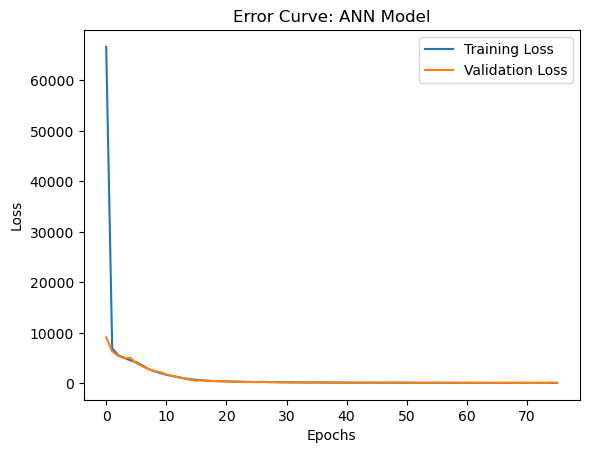

In [8]:
# Building the ANN model
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

ann_model.compile(optimizer='adam', loss='mse')

# Early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10)

# Training the model
history = ann_model.fit(X_train, y_train, validation_data=(X_test, y_test), 
                        epochs=100, callbacks=[early_stop], batch_size=32)

# Plotting the error curve
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Error Curve: ANN Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


## 9. Conclusion
We have successfully built and evaluated several regression models on the dataset. Based on the error curves, we identified the presence of overfitting/underfitting in some models. Further hyperparameter tuning and model adjustments may be necessary to improve performance.
